In [ ]:
import yfinance as yf
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

--- ML Data Preprocessing ---
                                 Open        High         Low       Close     Volume    Return       MA_20       MA_50  Volatility_20  Target
Date                                                                                                                                         
2025-08-01 00:00:00-04:00  210.036733  212.736031  200.703764  201.580292  104434500 -0.025004  210.004369  204.465843       0.008974       1
2025-08-04 00:00:00-04:00  203.701868  207.058561  200.883049  202.546463   75109300  0.004793  209.675674  204.490943       0.008460       0
2025-08-05 00:00:00-04:00  202.596248  204.528584  201.361157  202.118149   44155100 -0.002115  209.322575  204.522020       0.008450       1
2025-08-06 00:00:00-04:00  204.817449  214.528921  204.777599  212.407333  108483100  0.050907  209.427657  204.880199       0.014453       1
2025-08-07 00:00:00-04:00  218.015088  219.977305  215.724174  219.160538   90224800  0.031794  209.807151  205.275032

,Count
Target,
1,107
0,95


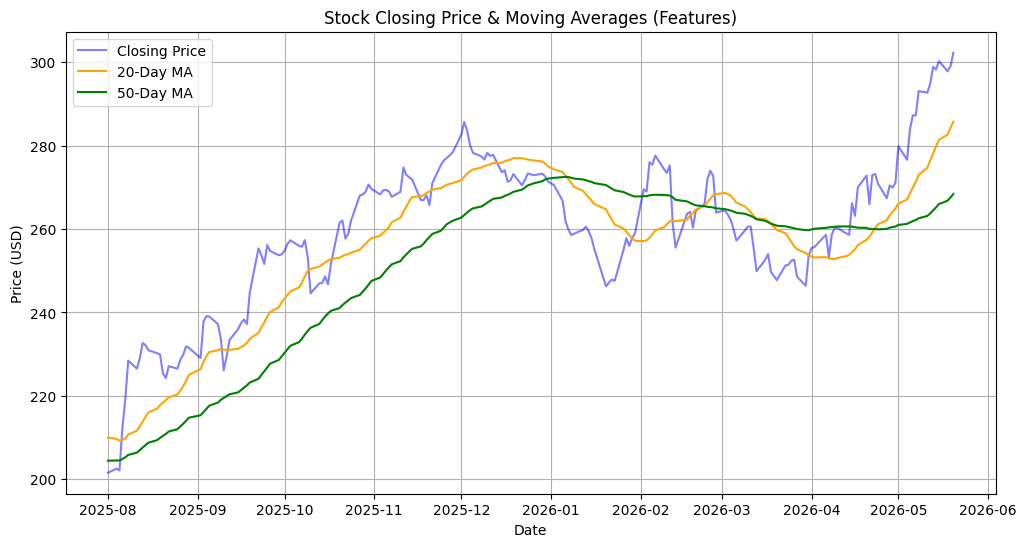

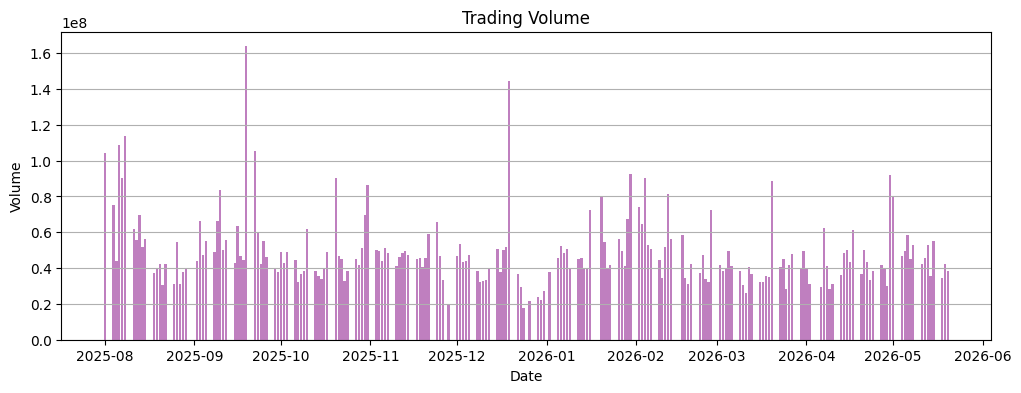

In [ ]:
from IPython.display import display

stock = yf.Ticker("AAPL")

df = stock.history(period='1y')

print("--- ML Data Preprocessing ---")

df.drop(['Dividends'], axis=1, inplace=True)
df.drop(['Stock Splits'], axis=1, inplace=True)

# 1. Feature Engineering
# Calculate daily returns
df['Return'] = df['Close'].pct_change()

# Calculate Moving Averages (trend indicators)
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

# Calculate Volatility (risk indicator)
df['Volatility_20'] = df['Return'].rolling(window=20).std()

# 2. Define Target Variable for ML
# Let's predict if the closing price will go UP (1) or DOWN (0) the next day
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 3. Handle Missing Values
df.dropna(inplace=True)

# Select features
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'MA_20', 'MA_50', 'Volatility_20']

Scaled Features (Values are now between 0 and 1):


,Open,High,Low,Close,Volume,Return,MA_20,MA_50,Volatility_20
Date,,,,,,,,,
2025-08-01 00:00:00-04:00,0.076200,0.083180,0.000000,0.000000,0.593317,0.247581,0.008924,0.000000,0.187884
2025-08-04 00:00:00-04:00,0.011323,0.025640,0.001841,0.009597,0.392227,0.542923,0.004621,0.000369,0.154908
2025-08-05 00:00:00-04:00,0.000000,0.000000,0.006751,0.005343,0.179966,0.474455,0.000000,0.000826,0.154229
2025-08-06 00:00:00-04:00,0.022748,0.101350,0.041836,0.107550,0.621080,1.000000,0.001375,0.006091,0.539571
2025-08-07 00:00:00-04:00,0.157909,0.156567,0.154251,0.174633,0.495878,0.810552,0.006342,0.011895,0.640536



Target Variable Class Distribution (y):


,Count
Target,
1,107
0,95


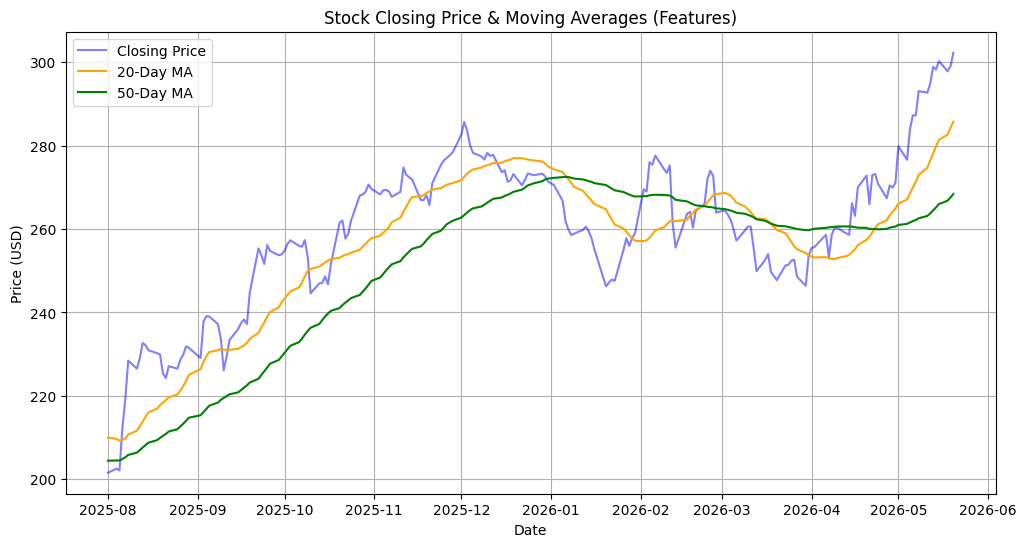

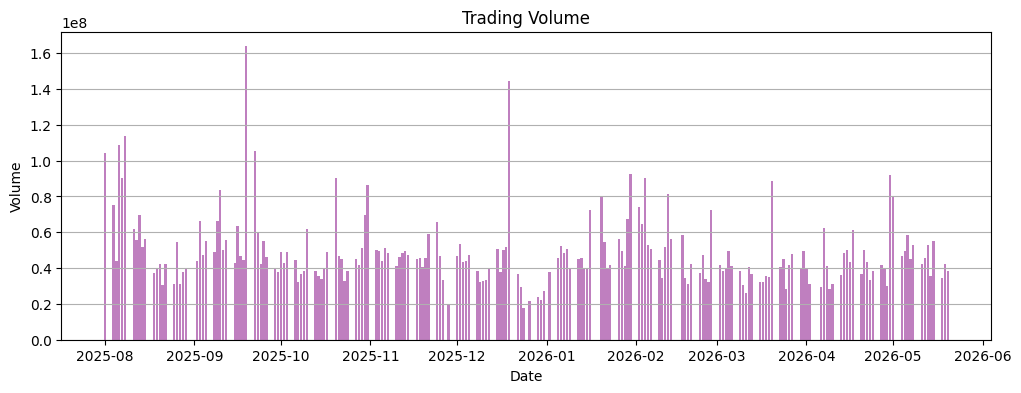

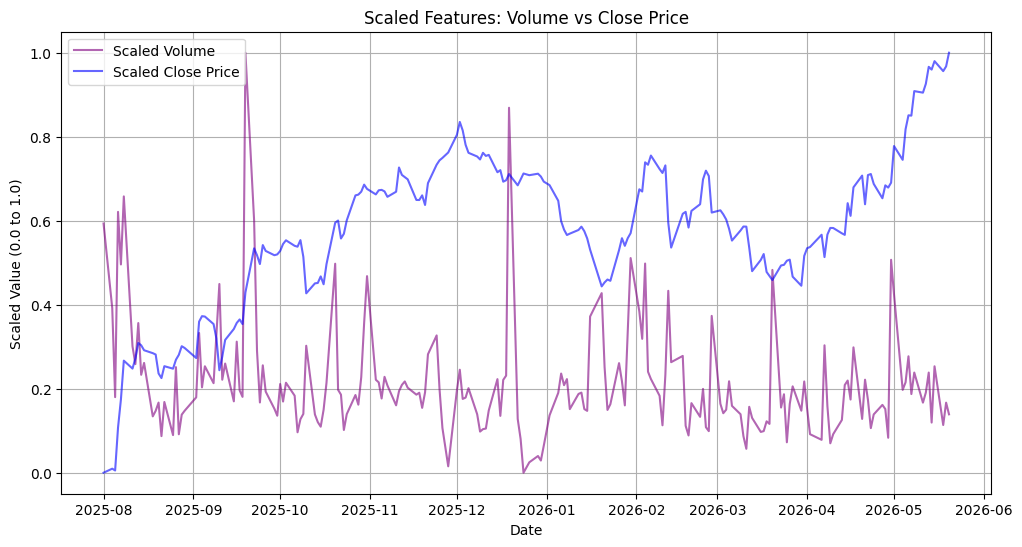

In [ ]:
X = df[features]
y = df['Target']

# 1. Initialize the MinMaxScaler
scaler = MinMaxScaler()

# 2. Fit the scaler to the features and transform them
X_scaled_array = scaler.fit_transform(X)

# 3. Convert the scaled array back into a DataFrame for easier handling and plotting
X = pd.DataFrame(X_scaled_array, columns=features, index=X.index)

print("Scaled Features (Values are now between 0 and 1):")
display(X.head())

# -----

print("\nTarget Variable Class Distribution (y):")
display(y.value_counts().to_frame("Count"))

# Plot 1: Closing Price with Moving Averages
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='Close', label='Closing Price', color='blue', alpha=0.5)
sns.lineplot(data=df, x=df.index, y='MA_20', label='20-Day MA', color='orange')
sns.lineplot(data=df, x=df.index, y='MA_50', label='50-Day MA', color='green')
plt.title('Stock Closing Price & Moving Averages (Features)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Trading Volume (Feature)
plt.figure(figsize=(12, 4))
plt.bar(df.index, df['Volume'], color='purple', alpha=0.5)
plt.title('Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(axis='y')
plt.show()

# Plot the Scaled Volume vs Scaled Close Price to show how they are comparable now
plt.figure(figsize=(12, 6))
plt.plot(X_scaled.index, X_scaled['Volume'], label='Scaled Volume', color='purple', alpha=0.6)
plt.plot(X_scaled.index, X_scaled['Close'], label='Scaled Close Price', color='blue', alpha=0.6)

plt.title('Scaled Features: Volume vs Close Price')
plt.xlabel('Date')
plt.ylabel('Scaled Value (0.0 to 1.0)')
plt.legend()
plt.grid(True)
plt.show()